# Sales Forecasting

Forecasting monthly revenue using time series decomposition and multiple approaches.
Using the e-commerce order data to predict next quarter's revenue.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 5), 'axes.titlesize': 13, 'font.size': 11})

print('Libraries loaded')

Libraries loaded


## 1. Data Preparation

In [2]:
orders = pd.read_csv('../../04_ecommerce_executive_dashboard/data/orders.csv', parse_dates=['order_date'])
orders['revenue'] = orders['quantity'] * orders['unit_price'] * (1 - orders['discount_pct'] / 100)
active = orders[orders['order_status'] != 'Cancelled'].copy()

# Monthly aggregation
monthly = active.set_index('order_date').resample('M').agg(
    revenue=('revenue', 'sum'),
    orders=('order_id', 'nunique'),
    customers=('customer_id', 'nunique'),
    avg_order_value=('revenue', 'mean'),
    total_quantity=('quantity', 'sum'),
).reset_index()

monthly.columns = ['month', 'revenue', 'orders', 'customers', 'aov', 'quantity']
monthly.to_csv('../data/monthly_sales.csv', index=False)

print(f'Monthly data: {len(monthly)} periods')
print(f'Revenue range: ${monthly["revenue"].min():,.0f} - ${monthly["revenue"].max():,.0f}')
print(monthly.tail())

Monthly data: 12 periods
Revenue range: $32,591 - $53,664
        month     revenue  orders  customers         aov  quantity
7  2025-02-28  32591.2145     333        291   97.871515       534
8  2025-03-31  48407.0465     499        415   97.008109       784
9  2025-04-30  51443.7100     486        400  105.851255       809
10 2025-05-31  50042.7660     531        422   94.242497       863
11 2025-06-30  52944.3595     546        446   96.967691       846


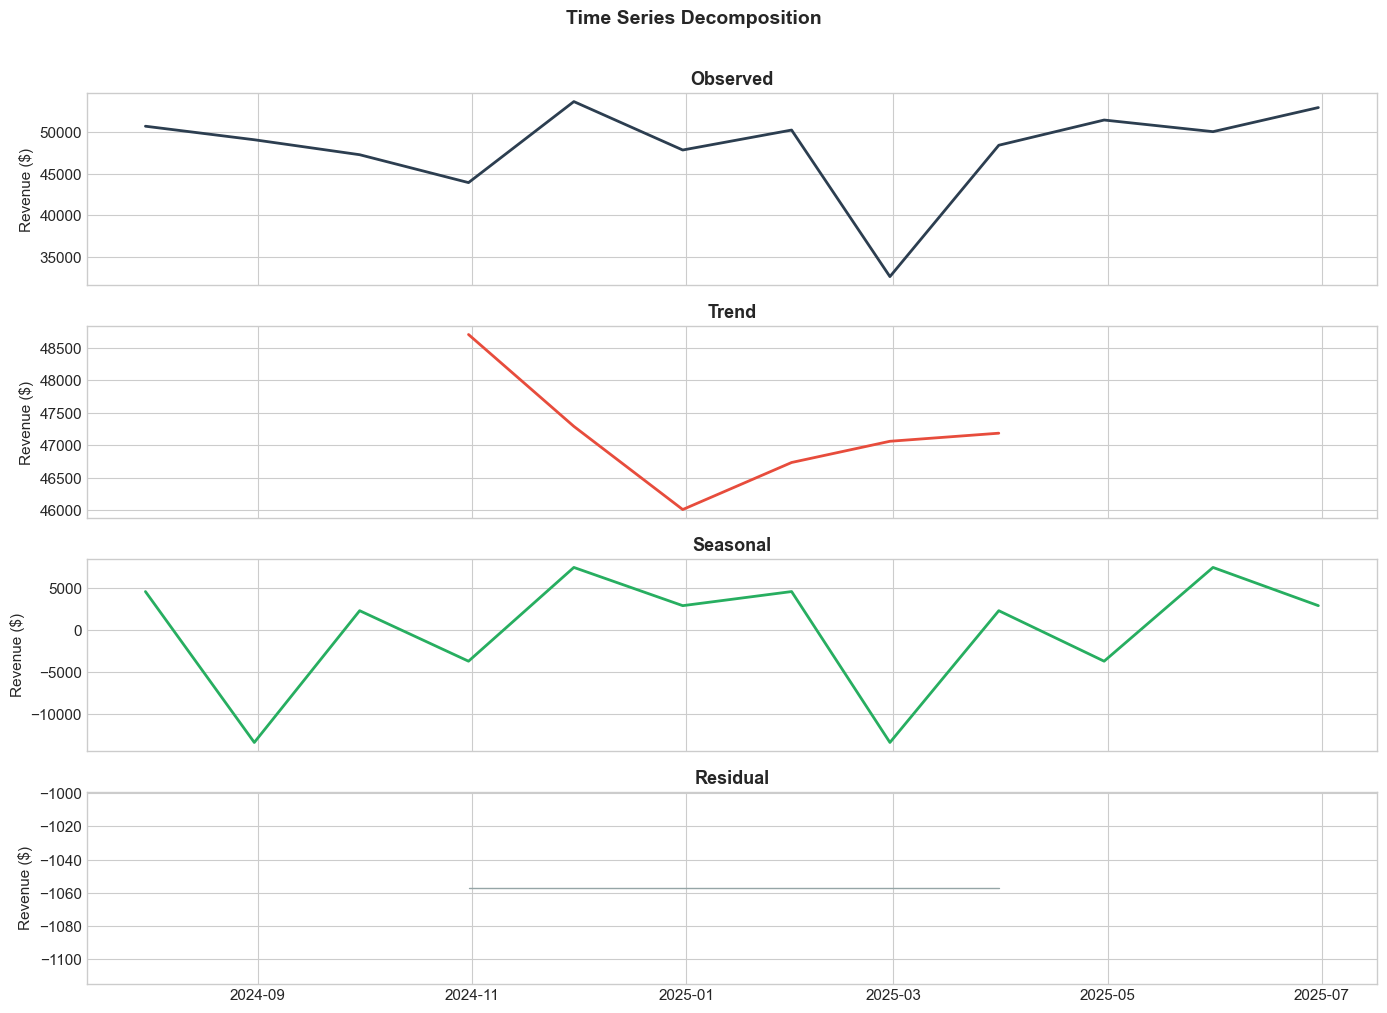

Saved decomposition.png


In [3]:
# Time series decomposition
ts = monthly.set_index('month')['revenue']
ts.index.freq = 'ME'

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Only decompose if we have enough data points
if len(ts) >= 6:
    decomp = seasonal_decompose(ts, model='additive', period=min(6, len(ts)//2))
    
    axes[0].plot(ts.index, ts.values, color='#2C3E50', lw=2)
    axes[0].set_title('Observed', fontweight='bold')
    axes[0].set_ylabel('Revenue ($)')
    
    axes[1].plot(ts.index, decomp.trend, color='#E74C3C', lw=2)
    axes[1].set_title('Trend', fontweight='bold')
    axes[1].set_ylabel('Revenue ($)')
    
    axes[2].plot(ts.index, decomp.seasonal, color='#27AE60', lw=2)
    axes[2].set_title('Seasonal', fontweight='bold')
    axes[2].set_ylabel('Revenue ($)')
    
    axes[3].plot(ts.index, decomp.resid, color='#95A5A6', lw=1)
    axes[3].set_title('Residual', fontweight='bold')
    axes[3].set_ylabel('Revenue ($)')
else:
    axes[0].plot(ts.index, ts.values, color='#2C3E50', lw=2)
    axes[0].set_title('Revenue (not enough data for full decomposition)', fontweight='bold')

plt.suptitle('Time Series Decomposition', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved decomposition.png')

## 2. Forecasting Models

Comparing three approaches:
1. **Holt-Winters** — classical exponential smoothing with trend + seasonality
2. **Linear Regression** with time features (trend + month dummies)
3. **Gradient Boosting** with lag features

In [4]:
# Train/test split: hold out last 2 months
n_test = 2
train = monthly.iloc[:-n_test].copy()
test = monthly.iloc[-n_test:].copy()

train_ts = train.set_index('month')['revenue']
train_ts.index.freq = 'ME'
test_ts = test.set_index('month')['revenue']
test_ts.index.freq = 'ME'

print(f'Train: {len(train)} months, Test: {len(test)} months')
print(f'Test months: {test["month"].dt.strftime("%Y-%m").tolist()}')

Train: 10 months, Test: 2 months
Test months: ['2025-05', '2025-06']


In [5]:
forecasts = {}

# 1. Holt-Winters
try:
    hw = ExponentialSmoothing(train_ts, trend='add', seasonal=None, damped_trend=True)
    hw_fit = hw.fit(optimized=True)
    hw_pred = hw_fit.forecast(n_test)
    forecasts['Holt-Winters'] = hw_pred.values
    print(f'Holt-Winters MAE: ${mean_absolute_error(test_ts, hw_pred):,.0f}')
except Exception as e:
    print(f'Holt-Winters failed: {e}')

# 2. Linear Regression with features
def make_features(df):
    feat = pd.DataFrame()
    feat['month_num'] = range(len(df))
    feat['month_of_year'] = df['month'].dt.month
    feat['quarter'] = df['month'].dt.quarter
    return feat

train_feat = make_features(train)
test_feat = pd.DataFrame({
    'month_num': range(len(train), len(train) + len(test)),
    'month_of_year': test['month'].dt.month.values,
    'quarter': test['month'].dt.quarter.values,
})

lr = LinearRegression()
lr.fit(train_feat, train['revenue'])
lr_pred = lr.predict(test_feat)
forecasts['Linear Regression'] = lr_pred
print(f'Linear Regression MAE: ${mean_absolute_error(test["revenue"], lr_pred):,.0f}')

# 3. Gradient Boosting with lag features
def make_lag_features(series, n_lags=3):
    df = pd.DataFrame({'revenue': series.values})
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = df['revenue'].shift(lag)
    df['rolling_mean_3'] = df['revenue'].rolling(3).mean().shift(1)
    df['month_idx'] = range(len(df))
    return df.dropna()

all_rev = monthly['revenue'].values
lag_df = make_lag_features(pd.Series(all_rev))

lag_train = lag_df.iloc[:-n_test]
lag_test = lag_df.iloc[-n_test:]

gb = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3)
gb_feats = [c for c in lag_df.columns if c != 'revenue']
gb.fit(lag_train[gb_feats], lag_train['revenue'])
gb_pred = gb.predict(lag_test[gb_feats])
forecasts['Gradient Boosting'] = gb_pred
print(f'Gradient Boosting MAE: ${mean_absolute_error(test["revenue"], gb_pred):,.0f}')

Holt-Winters MAE: $5,597
Linear Regression MAE: $5,010
Gradient Boosting MAE: $9,433


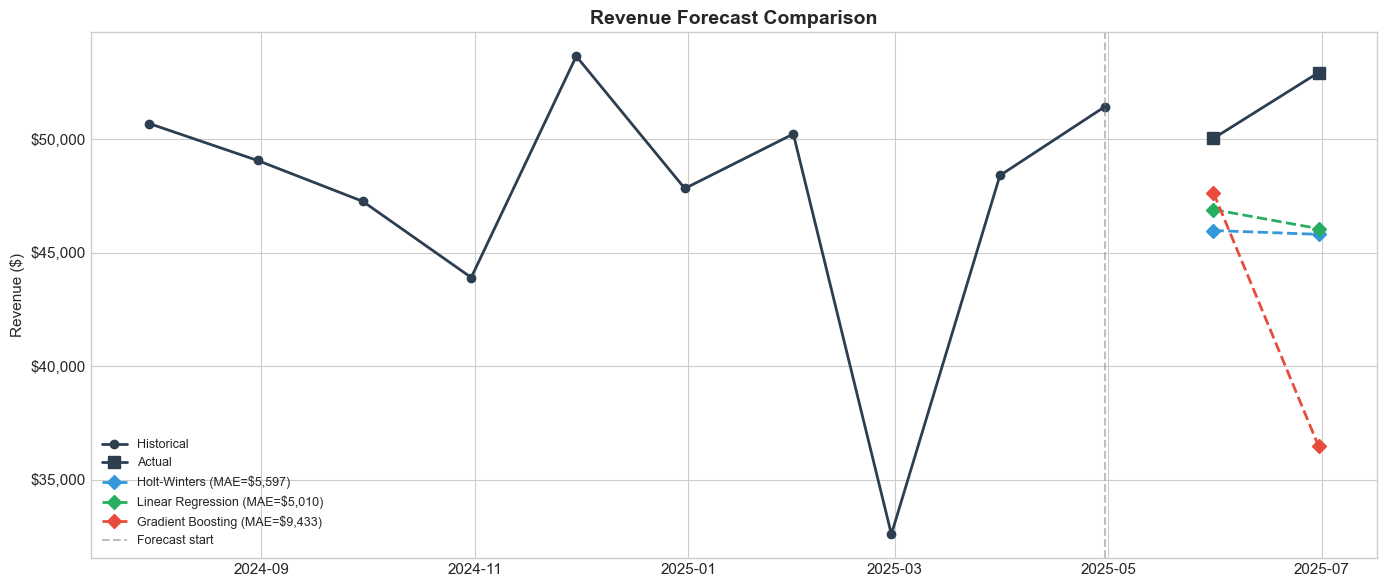

Saved forecast_comparison.png


In [6]:
# Plot all forecasts vs actual
fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(train['month'], train['revenue'], 'o-', color='#2C3E50', lw=2, label='Historical')
ax.plot(test['month'], test['revenue'], 's-', color='#2C3E50', lw=2, markersize=8, label='Actual')

# Forecasts
colors = {'Holt-Winters': '#3498DB', 'Linear Regression': '#27AE60', 'Gradient Boosting': '#E74C3C'}
for name, pred in forecasts.items():
    mae = mean_absolute_error(test['revenue'], pred)
    ax.plot(test['month'], pred, 'D--', color=colors[name], lw=2, markersize=7,
            label=f'{name} (MAE=${mae:,.0f})')

ax.axvline(train['month'].iloc[-1], color='gray', ls='--', alpha=0.5, label='Forecast start')
ax.set_title('Revenue Forecast Comparison', fontweight='bold', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Revenue ($)')
ax.legend(loc='best', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../outputs/forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved forecast_comparison.png')

## 3. Next Quarter Forecast

In [7]:
# Use the best performing model to forecast 3 months ahead
best_model_name = min(forecasts, key=lambda k: mean_absolute_error(test['revenue'], forecasts[k]))
print(f'Best model: {best_model_name}')
print()

# Refit on full data
full_ts = monthly.set_index('month')['revenue']
full_ts.index.freq = 'ME'

if best_model_name == 'Holt-Winters':
    final_model = ExponentialSmoothing(full_ts, trend='add', seasonal=None, damped_trend=True).fit()
    future_pred = final_model.forecast(3)
elif best_model_name == 'Linear Regression':
    full_feat = make_features(monthly)
    lr_final = LinearRegression().fit(full_feat, monthly['revenue'])
    future_months = pd.date_range(monthly['month'].max() + pd.DateOffset(months=1), periods=3, freq='ME')
    future_feat = pd.DataFrame({
        'month_num': range(len(monthly), len(monthly) + 3),
        'month_of_year': future_months.month,
        'quarter': future_months.quarter,
    })
    future_pred = pd.Series(lr_final.predict(future_feat), index=future_months)
else:
    # For GB, we need to iteratively predict
    full_lag = make_lag_features(pd.Series(monthly['revenue'].values))
    gb_final = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3)
    gb_final.fit(full_lag[gb_feats], full_lag['revenue'])
    
    recent = list(monthly['revenue'].values)
    future_preds = []
    for i in range(3):
        row = {
            'lag_1': recent[-1], 'lag_2': recent[-2], 'lag_3': recent[-3],
            'rolling_mean_3': np.mean(recent[-3:]),
            'month_idx': len(recent)
        }
        pred = gb_final.predict(pd.DataFrame([row]))[0]
        future_preds.append(pred)
        recent.append(pred)
    
    future_months = pd.date_range(monthly['month'].max() + pd.DateOffset(months=1), periods=3, freq='ME')
    future_pred = pd.Series(future_preds, index=future_months)

print('Next Quarter Revenue Forecast:')
for date, val in future_pred.items():
    print(f'  {date.strftime("%B %Y")}: ${val:,.0f}')
print(f'\nQ Total: ${future_pred.sum():,.0f}')
print(f'Last Q Actual: ${monthly["revenue"].iloc[-3:].sum():,.0f}')
pct_change = (future_pred.sum() - monthly['revenue'].iloc[-3:].sum()) / monthly['revenue'].iloc[-3:].sum() * 100
print(f'Projected QoQ change: {pct_change:+.1f}%')

Best model: Linear Regression

Next Quarter Revenue Forecast:
  July 2025: $52,983
  August 2025: $53,003
  September 2025: $53,024

Q Total: $159,010
Last Q Actual: $154,431
Projected QoQ change: +3.0%


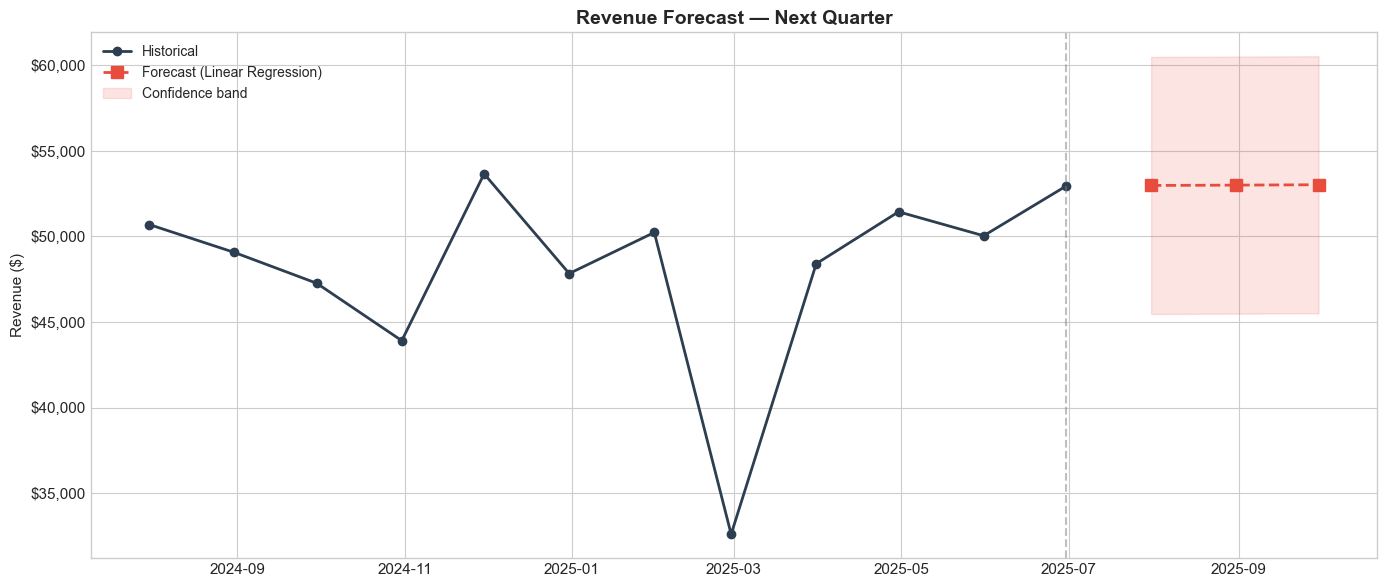

Saved next_quarter_forecast.png


In [8]:
# Final forecast plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly['month'], monthly['revenue'], 'o-', color='#2C3E50', lw=2, label='Historical')
ax.plot(future_pred.index, future_pred.values, 's--', color='#E74C3C', lw=2, markersize=8, label=f'Forecast ({best_model_name})')

# Add confidence band (rough estimate: +/- 1.5x the test MAE)
test_mae = mean_absolute_error(test['revenue'], forecasts[best_model_name])
ax.fill_between(future_pred.index, 
                future_pred.values - 1.5 * test_mae, 
                future_pred.values + 1.5 * test_mae,
                color='#E74C3C', alpha=0.15, label='Confidence band')

ax.axvline(monthly['month'].iloc[-1], color='gray', ls='--', alpha=0.5)
ax.set_title('Revenue Forecast — Next Quarter', fontweight='bold', fontsize=14)
ax.set_ylabel('Revenue ($)')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../outputs/next_quarter_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved next_quarter_forecast.png')